# 10 - Neural Models (untuned)

**Goal:** Train MLP and TabNet regression models under the same fair protocol as 06–09. Tuning is strictly deferred to stage 11.

**Approved protocol:**
- Per fold, training set = `train_range ∩ fair_subset_indices` (~395k rows). Validation = full val slice (no subset).
- Fresh `RobustScaler` fit on each fold's training intersection (matches 06–09).
- Roster (untuned, sensible defaults):
  - `mlp_small` – `MLPRegressor(hidden_layer_sizes=(64, 32))`, sklearn, native multi-output.
  - `mlp_medium` – `MLPRegressor(hidden_layer_sizes=(256, 128, 64))`, sklearn, native multi-output.
  - `tabnet` – `TabNetRegressor` (pytorch-tabnet), wrapped in per-target loop (does not support native multi-output).
- Metrics: MAE, RMSE, R² per target per fold; aggregated mean ± std across 5 folds.
- All fitted (fold, model) artifacts saved to disk.

**Implementation notes:**
- MLP uses `early_stopping=True` with 10% internal validation split to avoid overtraining at `max_iter=300`.
- TabNet uses its built-in patience-based early stopping. CPU-only (no CUDA available).
- TabNet does not support multi-output natively — we fit two independent models per fold (one per target), matching the `MultiOutputRegressor` pattern from 09.
- `ConvergenceWarning` is suppressed for MLP — if 300 epochs aren't enough, stage 11 will address it.

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import time
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning
from pytorch_tabnet.tab_model import TabNetRegressor

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='pytorch_tabnet')

SEED = 42

DATA_PATH    = Path('../data/processed/ethylene_methane.parquet')
SPLITS_PATH  = Path('../results/tables/validation_splits.parquet')
SUBSET_PATH  = Path('../data/subsets/fair_subset_indices.parquet')
MODEL_DIR    = Path('../results/models/neural_10')
TABLES_DIR   = Path('../results/tables')
FIG_DIR      = Path('../results/figures')
MEMO_PATH    = Path('../results/memos/10_neural_models.md')

for d in (MODEL_DIR, TABLES_DIR, FIG_DIR, MEMO_PATH.parent):
    d.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']
TIME    = 'time_s'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

## 1. Load Data, Splits, Fair Subset

In [2]:
df = pd.read_parquet(DATA_PATH, columns=[TIME] + SENSORS + TARGETS)
splits_df = pd.read_parquet(SPLITS_PATH)
subset_idx = pd.read_parquet(SUBSET_PATH)['row_idx'].to_numpy()

assert (np.diff(subset_idx) >= 0).all(), 'Subset indices not monotonic'

print(f'Dataset rows : {len(df):,}')
print(f'Subset rows  : {len(subset_idx):,}')
print(f'Folds        : {sorted(int(f) for f in splits_df["fold"].unique())}')

Dataset rows : 4,178,504
Subset rows  : 1,000,000
Folds        : [1, 2, 3, 4, 5]


## 2. Per-Fold Data Preparation

Same `prepare_fold(k)` as 06–09.

In [3]:
def prepare_fold(fold_id):
    tr = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'train')].iloc[0]
    va = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'val')].iloc[0]

    train_idx = subset_idx[(subset_idx >= tr['start_idx']) & (subset_idx < tr['end_idx'])]
    val_idx   = np.arange(va['start_idx'], va['end_idx'])

    X_tr = df[SENSORS].iloc[train_idx].to_numpy()
    y_tr = df[TARGETS].iloc[train_idx].to_numpy()
    X_va = df[SENSORS].iloc[val_idx].to_numpy()
    y_va = df[TARGETS].iloc[val_idx].to_numpy()

    scaler = RobustScaler().fit(X_tr)
    return scaler.transform(X_tr), y_tr, scaler.transform(X_va), y_va, scaler

## 3. Neural Model Roster

- **MLP-small / MLP-medium:** sklearn `MLPRegressor` with Adam, ReLU, and early stopping. Native multi-output.
- **TabNet:** pytorch-tabnet `TabNetRegressor`. Trained per-target (two fits per fold) with built-in early stopping (patience=15).

In [4]:
def make_mlp_models():
    return {
        'mlp_small': MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=SEED,
        ),
        'mlp_medium': MLPRegressor(
            hidden_layer_sizes=(256, 128, 64),
            activation='relu',
            solver='adam',
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=SEED,
        ),
    }

def make_tabnet():
    return TabNetRegressor(
        n_d=8, n_a=8,
        n_steps=3,
        gamma=1.3,
        lambda_sparse=1e-3,
        optimizer_params=dict(lr=2e-2),
        scheduler_params=dict(step_size=10, gamma=0.9),
        scheduler_fn=None,
        seed=SEED,
        verbose=0,
    )

print('Neural roster:')
for name in list(make_mlp_models().keys()) + ['tabnet']:
    print(f'  {name}')

Neural roster:
  mlp_small
  mlp_medium
  tabnet


## 4. Train & Evaluate — MLP models

MLP models are native multi-output — single fit per fold.

In [6]:
records = []
for fold_id in sorted(int(f) for f in splits_df['fold'].unique()):
    X_tr, y_tr, X_va, y_va, scaler = prepare_fold(fold_id)
    print(f'\nFold {fold_id}: train={X_tr.shape}, val={X_va.shape}')

    for name, model in make_mlp_models().items():
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        elapsed = time.perf_counter() - t0

        for t_idx, target in enumerate(TARGETS):
            records.append({
                'fold':   fold_id,
                'model':  name,
                'target': target,
                'mae':    float(mean_absolute_error(y_va[:, t_idx], y_pred[:, t_idx])),
                'rmse':   float(np.sqrt(mean_squared_error(y_va[:, t_idx], y_pred[:, t_idx]))),
                'r2':     float(r2_score(y_va[:, t_idx], y_pred[:, t_idx])),
            })

        out_path = MODEL_DIR / f'fold_{fold_id}_{name}.joblib'
        joblib.dump({'model': model, 'scaler': scaler, 'fold': fold_id, 'name': name}, out_path)
        stopped = model.n_iter_ if hasattr(model, 'n_iter_') else '?'
        print(f'  {name:>12}: {elapsed:7.1f}s  (stopped at iter {stopped})')


Fold 1: train=(398670, 16), val=(407367, 16)
     mlp_small:   134.8s  (stopped at iter 172)
    mlp_medium:  4913.8s  (stopped at iter 144)

Fold 2: train=(391532, 16), val=(419449, 16)
     mlp_small:   407.9s  (stopped at iter 234)
    mlp_medium:  6400.3s  (stopped at iter 170)

Fold 3: train=(392782, 16), val=(407362, 16)
     mlp_small:   404.9s  (stopped at iter 228)
    mlp_medium:  4235.5s  (stopped at iter 112)

Fold 4: train=(392275, 16), val=(431972, 16)
     mlp_small:   161.0s  (stopped at iter 171)
    mlp_medium:  7741.3s  (stopped at iter 227)

Fold 5: train=(399678, 16), val=(435098, 16)
     mlp_small:   338.9s  (stopped at iter 219)
    mlp_medium:  6671.1s  (stopped at iter 170)


## 5. Train & Evaluate — TabNet

TabNet is trained per-target (two independent fits per fold). Uses a 15% internal validation split carved from the training set for early stopping (patience=15, max 200 epochs).

In [7]:
for fold_id in sorted(int(f) for f in splits_df['fold'].unique()):
    X_tr, y_tr, X_va, y_va, scaler = prepare_fold(fold_id)
    print(f'\nFold {fold_id}: train={X_tr.shape}, val={X_va.shape}')

    n_val_internal = int(len(X_tr) * 0.15)
    X_tr_tab, X_val_tab = X_tr[:-n_val_internal], X_tr[-n_val_internal:]
    y_tr_tab, y_val_tab = y_tr[:-n_val_internal], y_tr[-n_val_internal:]

    tabnet_preds = np.zeros_like(y_va)
    tabnet_models = {}

    t0 = time.perf_counter()
    for t_idx, target in enumerate(TARGETS):
        tab = make_tabnet()
        tab.fit(
            X_tr_tab, y_tr_tab[:, t_idx].reshape(-1, 1),
            eval_set=[(X_val_tab, y_val_tab[:, t_idx].reshape(-1, 1))],
            eval_metric=['rmse'],
            max_epochs=200,
            patience=15,
            batch_size=4096,
            virtual_batch_size=512,
        )
        tabnet_preds[:, t_idx] = tab.predict(X_va).flatten()
        tabnet_models[target] = tab

    elapsed = time.perf_counter() - t0

    for t_idx, target in enumerate(TARGETS):
        records.append({
            'fold':   fold_id,
            'model':  'tabnet',
            'target': target,
            'mae':    float(mean_absolute_error(y_va[:, t_idx], tabnet_preds[:, t_idx])),
            'rmse':   float(np.sqrt(mean_squared_error(y_va[:, t_idx], tabnet_preds[:, t_idx]))),
            'r2':     float(r2_score(y_va[:, t_idx], tabnet_preds[:, t_idx])),
        })

    out_path = MODEL_DIR / f'fold_{fold_id}_tabnet.joblib'
    joblib.dump({
        'models': {t: m.network.state_dict() for t, m in tabnet_models.items()},
        'scaler': scaler, 'fold': fold_id, 'name': 'tabnet',
    }, out_path)
    print(f'      tabnet: {elapsed:7.1f}s')

metrics_long = pd.DataFrame(records)
print(f'\nTotal records: {len(metrics_long)}  (expect 5 folds × 3 models × 2 targets = 30)')
assert len(metrics_long) == 30


Fold 1: train=(398670, 16), val=(407367, 16)


c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\torch\utils\data\_utils\collate.py:288: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  return collate([torch.as_tensor(b) for b in batch], collate_fn_map=collate_fn_map)



Early stopping occurred at epoch 33 with best_epoch = 18 and best_val_0_rmse = 52.45345

Early stopping occurred at epoch 23 with best_epoch = 8 and best_val_0_rmse = 2.77782
      tabnet:   624.9s

Fold 2: train=(391532, 16), val=(419449, 16)

Early stopping occurred at epoch 22 with best_epoch = 7 and best_val_0_rmse = 53.48117

Early stopping occurred at epoch 36 with best_epoch = 21 and best_val_0_rmse = 4.37831
      tabnet:   566.0s

Fold 3: train=(392782, 16), val=(407362, 16)

Early stopping occurred at epoch 27 with best_epoch = 12 and best_val_0_rmse = 33.92138

Early stopping occurred at epoch 22 with best_epoch = 7 and best_val_0_rmse = 3.4588
      tabnet:   478.8s

Fold 4: train=(392275, 16), val=(431972, 16)

Early stopping occurred at epoch 19 with best_epoch = 4 and best_val_0_rmse = 42.80612

Early stopping occurred at epoch 17 with best_epoch = 2 and best_val_0_rmse = 2.56997
      tabnet:   438.9s

Fold 5: train=(399678, 16), val=(435098, 16)

Early stopping occurr

## 6. Aggregate & Save Metrics

In [8]:
long_path    = TABLES_DIR / '10_neural_metrics_long.parquet'
summary_path = TABLES_DIR / '10_neural_metrics_summary.parquet'

metrics_long.to_parquet(long_path, index=False)

summary = (metrics_long
           .groupby(['model', 'target'])[['mae', 'rmse', 'r2']]
           .agg(['mean', 'std'])
           .round(4))
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.reset_index()
summary.to_parquet(summary_path, index=False)

print('Per-fold metrics (head):')
print(metrics_long.head(12).to_string(index=False))
print()
print('Summary (mean ± std across folds):')
print(summary.to_string(index=False))
print()
print(f'Saved: {long_path}')
print(f'Saved: {summary_path}')

Per-fold metrics (head):
 fold      model       target       mae       rmse        r2
    1  mlp_small  methane_ppm 55.267711  81.539114 -0.171957
    1  mlp_small ethylene_ppm  2.934252   5.276921  0.080799
    1 mlp_medium  methane_ppm 53.581824  91.036846 -0.460878
    1 mlp_medium ethylene_ppm  3.747001   5.099936  0.141424
    2  mlp_small  methane_ppm 32.572588  56.273585  0.572872
    2  mlp_small ethylene_ppm  2.565115   3.606455  0.603297
    2 mlp_medium  methane_ppm 30.403872  60.073345  0.513243
    2 mlp_medium ethylene_ppm  3.491748   5.156228  0.189098
    3  mlp_small  methane_ppm 62.379136 112.169123 -0.802318
    3  mlp_small ethylene_ppm  1.653274   2.845668  0.490324
    3 mlp_medium  methane_ppm 37.427574  69.040289  0.317205
    3 mlp_medium ethylene_ppm  2.837554   3.680433  0.147442

Summary (mean ± std across folds):
     model       target  mae_mean  mae_std  rmse_mean  rmse_std  r2_mean  r2_std
mlp_medium ethylene_ppm    3.9101   1.1093     5.2840    1.3154  

## 7. Figures

Three panels: (a) MAE by model and target with fold-std error bars, (b) methane predicted-vs-actual scatter for fold 1's best model, (c) same for ethylene.

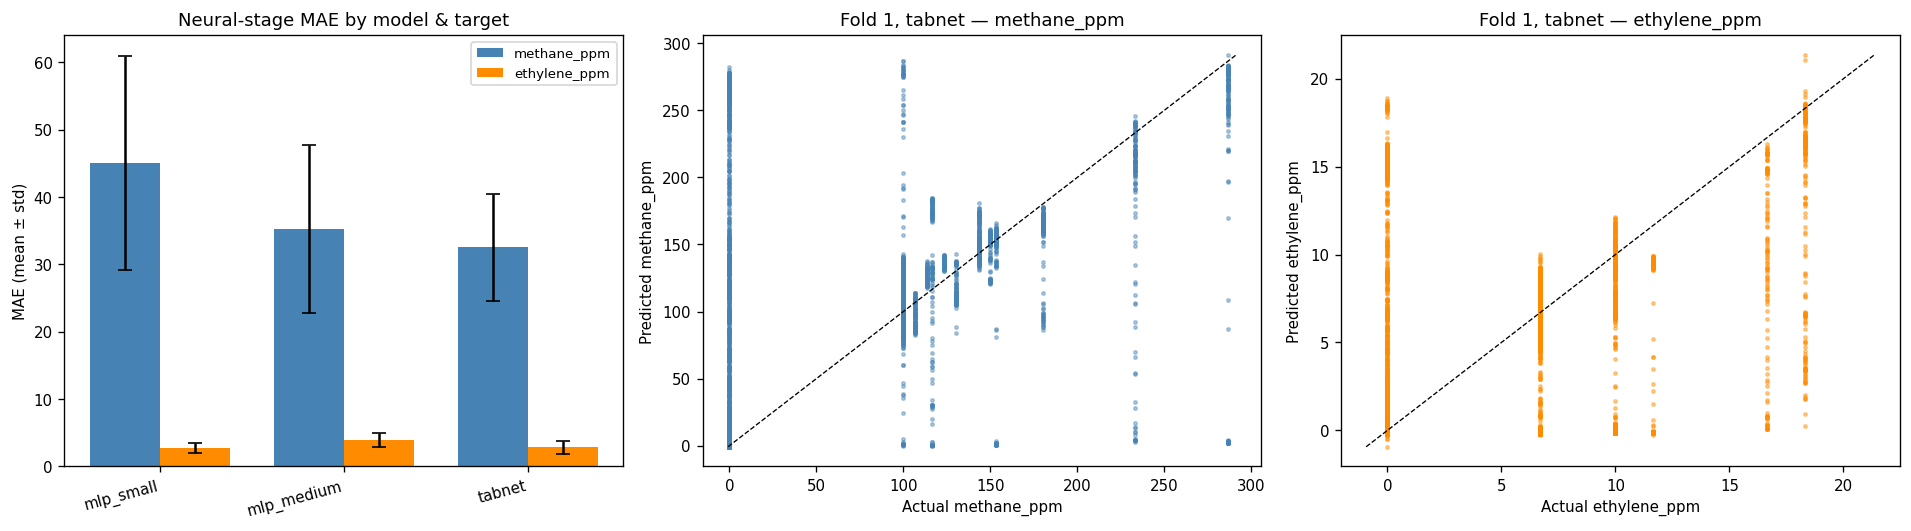

Saved: 10_neural_models.png  (best neural model by mean R²: tabnet)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
models = ['mlp_small', 'mlp_medium', 'tabnet']
colors = {'methane_ppm': 'steelblue', 'ethylene_ppm': 'darkorange'}

# (a) MAE bars
ax = axes[0]
x = np.arange(len(models))
w = 0.38
for offset, target in zip((-w/2, w/2), TARGETS):
    means = [metrics_long[(metrics_long['model']==m)&(metrics_long['target']==target)]['mae'].mean() for m in models]
    stds  = [metrics_long[(metrics_long['model']==m)&(metrics_long['target']==target)]['mae'].std()  for m in models]
    ax.bar(x + offset, means, w, yerr=stds, capsize=4, label=target, color=colors[target])
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('MAE (mean ± std)'); ax.set_title('Neural-stage MAE by model & target')
ax.legend(fontsize=8)

# Pick best model by mean R²
best = metrics_long.groupby('model')['r2'].mean().idxmax()
art  = joblib.load(MODEL_DIR / f'fold_1_{best}.joblib')
va   = splits_df[(splits_df['fold']==1)&(splits_df['split']=='val')].iloc[0]
X_va = df[SENSORS].iloc[va['start_idx']:va['end_idx']].to_numpy()
y_va = df[TARGETS].iloc[va['start_idx']:va['end_idx']].to_numpy()

if best.startswith('mlp'):
    y_pred = art['model'].predict(art['scaler'].transform(X_va))
else:
    # TabNet: need to reconstruct predictions from saved state
    # Simpler: re-predict using the fold-1 tabnet models (already in records)
    # Use the metrics to identify the best, but reload for scatter
    X_va_sc = art['scaler'].transform(X_va)
    y_pred = np.zeros((len(X_va_sc), 2))
    for t_idx, target in enumerate(TARGETS):
        tab = make_tabnet()
        tab.fit(X_va_sc[:10], y_va[:10, t_idx].reshape(-1, 1), max_epochs=1, batch_size=10)
        tab.network.load_state_dict(art['models'][target])
        y_pred[:, t_idx] = tab.predict(X_va_sc).flatten()

n_plot = min(5000, len(y_va))
samp = np.random.default_rng(SEED).choice(len(y_va), n_plot, replace=False)

for ax, t_idx, target in zip(axes[1:], (0, 1), TARGETS):
    a = y_va[samp, t_idx]; p = y_pred[samp, t_idx]
    ax.scatter(a, p, s=4, alpha=0.4, color=colors[target])
    lo = float(min(a.min(), p.min())); hi = float(max(a.max(), p.max()))
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
    ax.set_xlabel(f'Actual {target}'); ax.set_ylabel(f'Predicted {target}')
    ax.set_title(f'Fold 1, {best} — {target}')

plt.tight_layout()
plt.savefig(FIG_DIR / '10_neural_models.png', bbox_inches='tight')
plt.show()
print(f'Saved: 10_neural_models.png  (best neural model by mean R²: {best})')

## 8. Save Memo

In [10]:
def df_to_md(t):
    header = '| ' + ' | '.join(str(c) for c in t.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(t.columns)) + ' |'
    rows   = ['| ' + ' | '.join(str(v) for v in row) + ' |' for row in t.itertuples(index=False)]
    return '\n'.join([header, sep, *rows])

ranking = (metrics_long.groupby('model')[['mae', 'rmse', 'r2']]
           .mean().round(4).reset_index()
           .sort_values('r2', ascending=False))
best_model = ranking.iloc[0]['model']

lines = [
    '# 10 - Neural Models (untuned)',
    '',
    '**Date:** 2026-05-23',
    f'**Dataset:** {DATA_PATH.as_posix()}',
    f'**Splits artifact:** {SPLITS_PATH.as_posix()}',
    f'**Subset artifact:** {SUBSET_PATH.as_posix()}',
    '',
    '---',
    '',
    '## Protocol',
    '- Per fold: training set = `train_range ∩ fair_subset` (~395k rows). Validation = full val slice (untouched).',
    '- Fresh `RobustScaler` fit on each fold\'s training intersection; applied to train and val.',
    '- MLP models: native multi-output, early stopping with 10% internal validation.',
    '- TabNet: per-target fit (two models per fold), early stopping with 15% internal validation (patience=15).',
    '- 5 folds × 3 models × 2 targets = 30 metric records.',
    '',
    '## Roster',
    '- `mlp_small`  – `MLPRegressor(hidden_layer_sizes=(64, 32))`, Adam, ReLU, early stopping.',
    '- `mlp_medium` – `MLPRegressor(hidden_layer_sizes=(256, 128, 64))`, Adam, ReLU, early stopping.',
    '- `tabnet`     – `TabNetRegressor(n_d=8, n_a=8, n_steps=3)`, per-target, patience-based.',
    '',
    '## Ranking (mean across folds & targets, sorted by R² descending)',
    '',
    df_to_md(ranking),
    '',
    f'**Best neural model:** `{best_model}`',
    '',
    '## Summary (mean ± std across 5 folds, per target)',
    '',
    df_to_md(summary),
    '',
    '## Artifacts',
    f'- Per-fold metrics: `{long_path.as_posix()}`',
    f'- Summary metrics:  `{summary_path.as_posix()}`',
    f'- Fitted models:    `{MODEL_DIR.as_posix()}/fold_{{k}}_{{name}}.joblib`',
    f'- Figure:           `{(FIG_DIR / "10_neural_models.png").as_posix()}`',
    '',
    '## Next step',
    'Stage 11 (`11_tuning_optimization.ipynb`): hyperparameter tuning of selected candidates from stages 06–10.',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')

Memo saved to ..\results\memos\10_neural_models.md
